In [18]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/softec-26-ml-competition/sample_submission.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/main_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/drg_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/cpt_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/icd_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/dob_df.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/main_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/cpt_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/drg_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/icd_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/dob_df.csv


In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [3]:
# Train
main_train = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/main_df_train.csv")
cpt_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/cpt_df_train.csv")
icd_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/icd_df_train.csv")
drg_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/drg_df_train.csv")
dob_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/dob_df.csv")

# Test
main_test = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/main_df_test.csv")
cpt_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/cpt_df_test.csv")
icd_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/icd_df_test.csv")
drg_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/drg_df_test.csv")
dob_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/dob_df.csv")

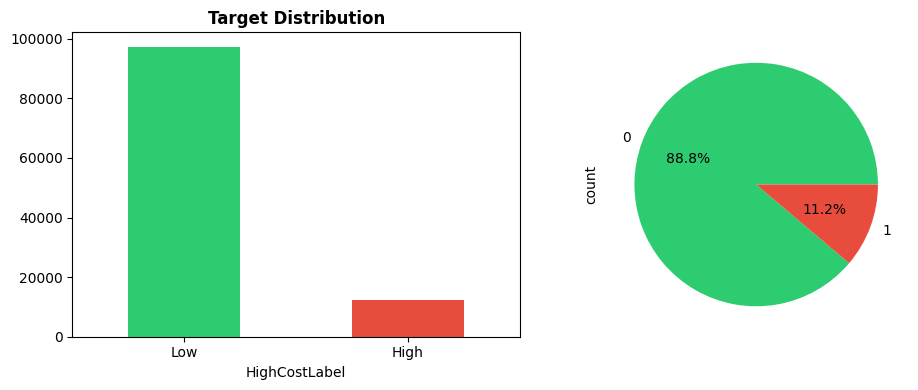

In [4]:
# Filter and create target
main_train = main_train[main_train["MONTH"].isin([-1, 12])]
main_test  = main_test[main_test["MONTH"].isin([-1, 12])]
main_train["HighCostLabel"] = (main_train["NEXT_YEAR_COST"] > 30000).astype(int)

# Visualize target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
main_train["HighCostLabel"].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title("Target Distribution", fontweight='bold')
axes[0].set_xticklabels(['Low', 'High'], rotation=0)
main_train["HighCostLabel"].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                 colors=['#2ecc71', '#e74c3c'])
plt.tight_layout()
plt.show()

In [5]:
# Feature engineering
def main_features(df):
    df["cost_ratio_inpatient"]  = df["Inpatient_Cost"] / (df["TotalCost"] + 1)
    df["cost_ratio_outpatient"] = df["OutpatientVisits_Cost"] / (df["TotalCost"] + 1)
    df["hcc_change_1yr"] = df["MemberHccScore"] - df["MemberHccScoreLastYear"]
    df["hcc_change_2yr"] = df["MemberHccScore"] - df["MemberHccScoreLastTwoYear"]
    df["visit_per_claim"] = df["ProviderVisitCount"] / (df["TotalClaims"] + 1)
    df["emergency_ratio"] = df["EmergencyDepartmentVisits"] / (df["ProviderVisitCount"] + 1)
    df["chronic_ratio"] = df["ChronicConditions"] / (df["TotalClaims"] + 1)
    df["cost_per_claim"] = df["TotalCost"] / (df["TotalClaims"] + 1)
    df["admission_ratio"] = df["Inpatient"] / (df["ProviderVisitCount"] + 1)
    return df

main_train = main_features(main_train)
main_test  = main_features(main_test)

In [6]:
# Aggregate CPT, ICD, DRG codes
def agg_features(df, possible_cols):
    col = None
    for c in possible_cols:
        if c in df.columns:
            col = c
            break
    if col is None:
        return pd.DataFrame(columns=["Member_Key","YEAR"])
    agg = df.groupby(["Member_Key","YEAR"])[col].agg(["count","nunique"])
    agg.columns = [f"{col}_count", f"{col}_nunique"]
    return agg.reset_index()

cpt_tr = agg_features(cpt_train, ["CPT_Code","CPT"])
cpt_te = agg_features(cpt_test, ["CPT_Code","CPT"])
icd_tr = agg_features(icd_train, ["ICD_Code","ICD"])
icd_te = agg_features(icd_test, ["ICD_Code","ICD"])
drg_tr = agg_features(drg_train, ["DRG_Code","DRG"])
drg_te = agg_features(drg_test, ["DRG_Code","DRG"])

In [7]:
# Merge all data
def merge_all(main, cpt, icd, drg, dob):
    df = main.copy()
    for d in [cpt, icd, drg]:
        if len(d.columns) > 2:
            df = df.merge(d, on=["Member_Key","YEAR"], how="left")
    df = df.merge(dob, on="Member_Key", how="left")
    return df

train = merge_all(main_train, cpt_tr, icd_tr, drg_tr, dob_train)
test  = merge_all(main_test,  cpt_te, icd_te, drg_te, dob_test)

In [8]:
# Data cleaning
leak_cols = ["NEXT_YEAR_COST", "Leakage_Cost", "PredictedCost"]
train = train.drop(columns=leak_cols, errors="ignore")
test  = test.drop(columns=leak_cols, errors="ignore")

drop_cols = ["Member_Key"]
X_cols = [c for c in train.columns if c not in drop_cols + ["HighCostLabel"]]

num_cols = train[X_cols].select_dtypes(include=np.number).columns
train[num_cols] = train[num_cols].fillna(train[num_cols].median())
test[num_cols]  = test[num_cols].fillna(test[num_cols].median())

## Phase 1: Feature Engineering

# Interaction features
for df in [train, test]:
    df["HCC_x_Cost"] = df["MemberHccScore"] * df["TotalCost"]
    df["HCC_x_Inpatient"] = df["MemberHccScore"] * df["Inpatient"]
    df["HCC_x_Emergency"] = df["MemberHccScore"] * df["EmergencyDepartmentVisits"]
    df["Inpatient_Cost_x_Chronic"] = df["Inpatient_Cost"] * df["ChronicConditions"]
    df["Visit_x_Emergency"] = df["ProviderVisitCount"] * df["EmergencyDepartmentVisits"]
    df["log_cost_per_claim"] = np.log1p(df["cost_per_claim"])
    df["log_total_cost"] = np.log1p(df["TotalCost"])
    df["log_hcc_score"] = np.log1p(df["MemberHccScore"])
    df["HCC_trend_accel"] = df["hcc_change_1yr"] - df["hcc_change_2yr"]
    df["cost_per_visit"] = df["TotalCost"] / (df["ProviderVisitCount"] + 1)

In [10]:
# Encode categorical
cat_cols = train.select_dtypes(include="object").columns
for col in cat_cols:
    full = pd.concat([train[col], test[col]]).astype(str)
    le = LabelEncoder()
    le.fit(full)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

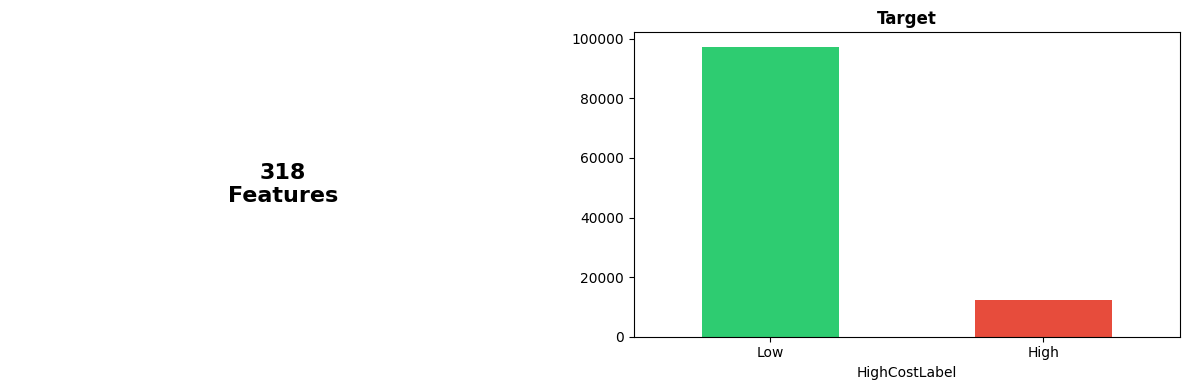

In [11]:
# Prepare features
train_data = train[train["YEAR"] < 2024]
X = train_data.drop(["HighCostLabel","Member_Key"], axis=1)
y = train_data["HighCostLabel"]
X_test = test.drop(["Member_Key"], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].text(0.5, 0.5, f"{X.shape[1]}\nFeatures", ha='center', va='center', fontsize=16, fontweight='bold')
axes[0].axis('off')
y.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title("Target", fontweight='bold')
axes[1].set_xticklabels(['Low', 'High'], rotation=0)
plt.tight_layout()
plt.show()

## Phase 2: Ensemble Training (5-Fold CV)

In [12]:
# Initialize storage for predictions
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))
test_preds_xgb = np.zeros(len(X_test))
test_preds_cat = np.zeros(len(X_test))

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos_weight = (y==0).sum() / (y==1).sum()

In [15]:
for fold, (tr_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/5")
    print(f"{'='*60}")
    
    X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    # ==================== LIGHTGBM ====================
    print(f"\n🔹 Training LightGBM...")
    lgb_model = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=4
    )
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="auc")
    
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_preds_lgb += lgb_model.predict_proba(X_test)[:, 1] / 5
    
    lgb_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    print(f"   LGB AUC: {lgb_auc:.4f}")

    # ==================== XGBOOST ====================
    print(f"\n🔹 Training XGBoost...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=4,
        verbosity=0
    )
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]
    test_preds_xgb += xgb_model.predict_proba(X_test)[:, 1] / 5
    
    xgb_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    print(f"   XGB AUC: {xgb_auc:.4f}")

     # ==================== CATBOOST ====================
    print(f"\n🔹 Training CatBoost...")
    cat_model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.03,
        depth=8,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbose=False
    )
    cat_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    
    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]
    test_preds_cat += cat_model.predict_proba(X_test)[:, 1] / 5
    
    cat_auc = roc_auc_score(y_val, oof_cat[val_idx])
    print(f"   CAT AUC: {cat_auc:.4f}")
    
    print(f"\n   Fold Average: {(lgb_auc + xgb_auc + cat_auc) / 3:.4f}")


FOLD 1/5

🔹 Training LightGBM...
[LightGBM] [Info] Number of positive: 9798, number of negative: 77851
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 29714
[LightGBM] [Info] Number of data points in the train set: 87649, number of used features: 264
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111787 -> initscore=-2.072618
[LightGBM] [Info] Start training from score -2.072618
   LGB AUC: 0.7853

🔹 Training XGBoost...
   XGB AUC: 0.7898

🔹 Training CatBoost...
   CAT AUC: 0.7917

   Fold Average: 0.7890

FOLD 2/5

🔹 Training LightGBM...
[LightGBM] [Info] Number of positive: 9798, number of negative: 77851
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memor

Individual Model AUC: LGB=0.7892 | XGB=0.7910 | CAT=0.7973


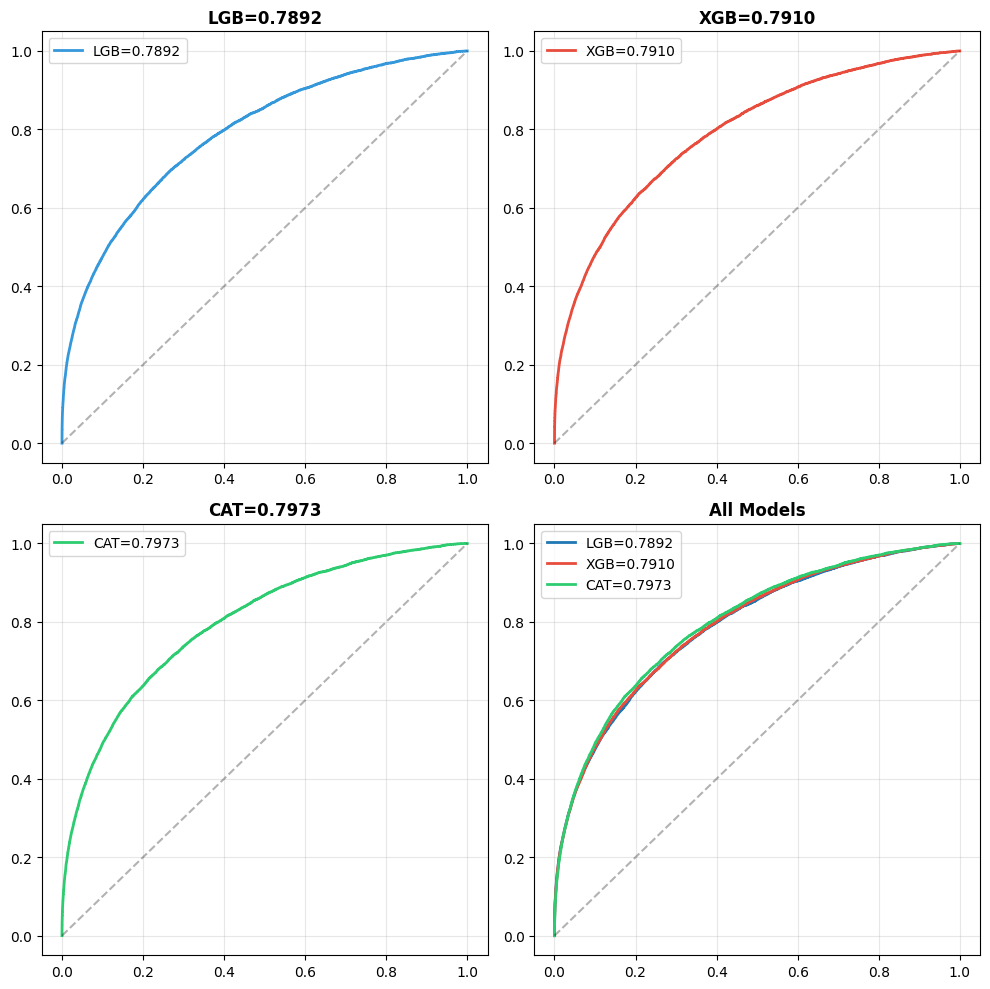

In [16]:
# Model performance
lgb_auc = roc_auc_score(y, oof_lgb)
xgb_auc = roc_auc_score(y, oof_xgb)
cat_auc = roc_auc_score(y, oof_cat)
print(f"Individual Model AUC: LGB={lgb_auc:.4f} | XGB={xgb_auc:.4f} | CAT={cat_auc:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, (preds, label, color) in zip([axes[0,0], axes[0,1], axes[1,0]], 
                                      [(oof_lgb, f'LGB={lgb_auc:.4f}', '#3498db'),
                                       (oof_xgb, f'XGB={xgb_auc:.4f}', '#e74c3c'),
                                       (oof_cat, f'CAT={cat_auc:.4f}', '#2ecc71')]):
    fpr, tpr, _ = roc_curve(y, preds)
    ax.plot(fpr, tpr, label=label, linewidth=2, color=color)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(label, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

fpr_l, tpr_l, _ = roc_curve(y, oof_lgb)
fpr_x, tpr_x, _ = roc_curve(y, oof_xgb)
fpr_c, tpr_c, _ = roc_curve(y, oof_cat)
axes[1,1].plot(fpr_l, tpr_l, label=f'LGB={lgb_auc:.4f}', linewidth=2)
axes[1,1].plot(fpr_x, tpr_x, label=f'XGB={xgb_auc:.4f}', linewidth=2, color='#e74c3c')
axes[1,1].plot(fpr_c, tpr_c, label=f'CAT={cat_auc:.4f}', linewidth=2, color='#2ecc71')
axes[1,1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1,1].set_title('All Models', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best Ensemble AUC: 0.7986
Optimal Weights: LGB=0.300, XGB=0.200, CAT=0.500


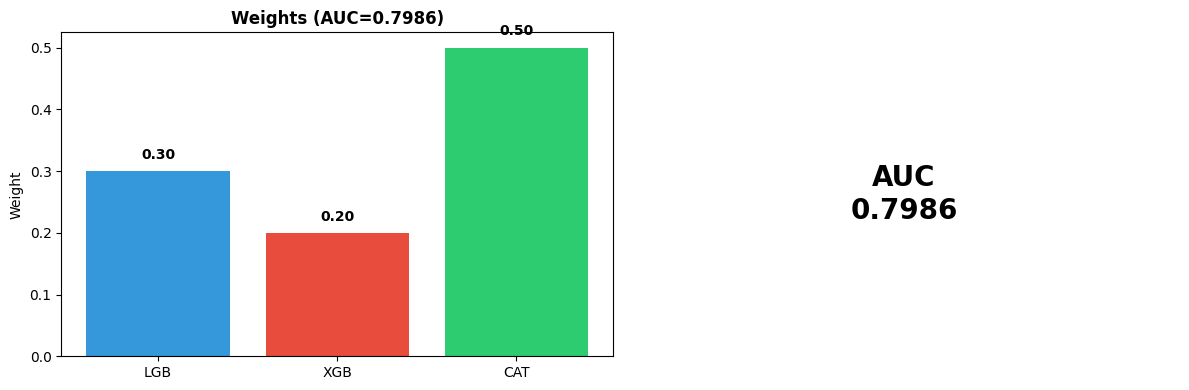

In [24]:
# Find optimal weights
best_auc = 0
best_weights = (1/3, 1/3, 1/3)

for w_lgb in [0.3, 0.4, 0.5, 0.6]:
    for w_xgb in [0.2, 0.3, 0.4, 0.5]:
        w_cat = 1 - w_lgb - w_xgb
        if w_cat < 0 or w_cat > 1:
            continue
        oof_blend = w_lgb * oof_lgb + w_xgb * oof_xgb + w_cat * oof_cat
        auc = roc_auc_score(y, oof_blend)
        if auc > best_auc:
            best_auc = auc
            best_weights = (w_lgb, w_xgb, w_cat)

print(f"Best Ensemble AUC: {best_auc:.4f}")
print(f"Optimal Weights: LGB={best_weights[0]:.3f}, XGB={best_weights[1]:.3f}, CAT={best_weights[2]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['LGB', 'XGB', 'CAT'], list(best_weights), color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title(f'Weights (AUC={best_auc:.4f})', fontweight='bold')
axes[0].set_ylabel('Weight')
for i, v in enumerate(best_weights):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].text(0.5, 0.5, f'AUC\n{best_auc:.4f}', ha='center', va='center', fontsize=20, fontweight='bold')

axes[1].axis('off')
plt.tight_layout()
plt.show()

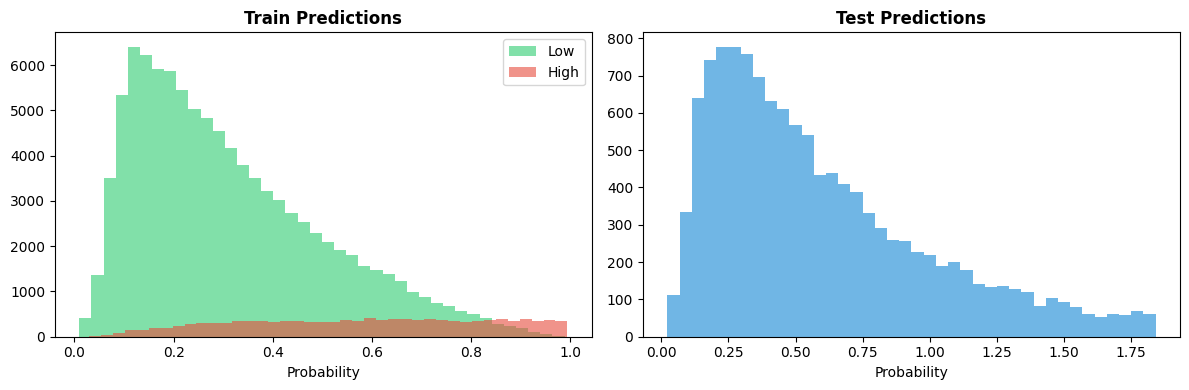

In [25]:
# Ensemble predictions
oof_ensemble = best_weights[0] * oof_lgb + best_weights[1] * oof_xgb + best_weights[2] * oof_cat
test_preds_ensemble = best_weights[0] * test_preds_lgb + best_weights[1] * test_preds_xgb + best_weights[2] * test_preds_cat

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(oof_ensemble[y==0], bins=40, alpha=0.6, label='Low', color='#2ecc71')
axes[0].hist(oof_ensemble[y==1], bins=40, alpha=0.6, label='High', color='#e74c3c')
axes[0].set_title('Train Predictions', fontweight='bold')
axes[0].set_xlabel('Probability')
axes[0].legend()
axes[1].hist(test_preds_ensemble, bins=40, alpha=0.7, color='#3498db')
axes[1].set_title('Test Predictions', fontweight='bold')
axes[1].set_xlabel('Probability')
plt.tight_layout()
plt.show()

## Phase 3: Threshold Optimization

Optimal Threshold: 0.63 (F1=0.4305)


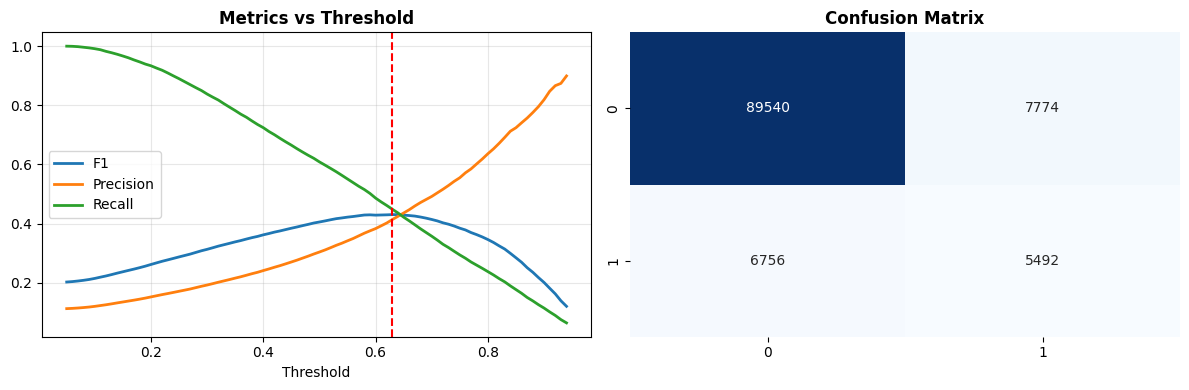

In [26]:
# Find optimal threshold
best_f1 = 0
best_thresh = 0.5
threshold_results = []

for t in np.arange(0.05, 0.95, 0.01):
    preds = (oof_ensemble > t).astype(int)
    f1 = f1_score(y, preds)
    threshold_results.append({
        'threshold': t,
        'f1': f1,
        'precision': precision_score(y, preds),
        'recall': recall_score(y, preds)
    })
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

final_preds_val = (oof_ensemble > best_thresh).astype(int)
thresh_df = pd.DataFrame(threshold_results)
print(f"Optimal Threshold: {best_thresh:.2f} (F1={best_f1:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresh_df['threshold'], thresh_df['f1'], label='F1', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', linewidth=2)
axes[0].axvline(best_thresh, color='r', linestyle='--')
axes[0].set_title('Metrics vs Threshold', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

cm = confusion_matrix(y, final_preds_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# submission
final_test_preds = (test_preds_ensemble > best_thresh).astype(int)
submission = pd.DataFrame({
    "Member_Key": test["Member_Key"],
    "HighCostLabel": final_test_preds
})
submission = submission.drop_duplicates(subset=["Member_Key"])
submission = submission.sort_values("Member_Key").reset_index(drop=True)
submission.to_csv("submission.csv", index=False)

print(f"Submission: {submission.shape}")
print(f"High-cost: {(submission['HighCostLabel']==1).sum()}")

Submission: (12387, 2)
High-cost: 4600


## Phase 4: Validation

In [28]:
# Final validation
print("Validation:")
print(f"Shape: {submission.shape}")
print(f"Missing: {submission.isnull().sum().sum()}")
print(f"Duplicates: {submission.duplicated(subset=['Member_Key']).sum()}")
print(f"Class split: {submission['HighCostLabel'].value_counts().to_dict()}")
print(f"\nMetrics (train OOF):")
print(f"Precision: {precision_score(y, final_preds_val):.4f}")
print(f"Recall: {recall_score(y, final_preds_val):.4f}")
print(f"F1: {f1_score(y, final_preds_val):.4f}")
print(f"AUC: {roc_auc_score(y, oof_ensemble):.4f}")

Validation:
Shape: (12387, 2)
Missing: 0
Duplicates: 0
Class split: {0: 7787, 1: 4600}

Metrics (train OOF):
Precision: 0.4140
Recall: 0.4484
F1: 0.4305
AUC: 0.7986
